In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter

/home/s6moakba/miniconda3/envs/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
model_checkpoint = 'allenai/tk-instruct-base-def-pos'
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
model = AutoModelForSeq2SeqLM.from_pretrained(model_checkpoint)

/home/s6moakba/miniconda3/envs/myenv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

T5ForConditionalGeneration(
  (shared): Embedding(32100, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32100, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

In [26]:
def get_embedding(text, pooling='mean', max_length=512):
    """
    Generate an embedding for the input text by passing it through the T5 encoder.
    """
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
    inputs = {k: v.to(device) for k, v in inputs.items()}
    encoder_outputs = model.encoder(**inputs)
    last_hidden_state = encoder_outputs.last_hidden_state  # shape: (batch_size, seq_length, hidden_size)
    
    if pooling == 'mean':
        attention_mask = inputs.get("attention_mask", None)
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).expand(last_hidden_state.size()).float()
            summed = torch.sum(last_hidden_state * mask, dim=1)
            counts = torch.clamp(mask.sum(dim=1), min=1e-9)
            pooled = summed / counts
        else:
            pooled = last_hidden_state.mean(dim=1)
    elif pooling == 'first':
        pooled = last_hidden_state[:, 0, :]
    else:
        raise ValueError("Unsupported pooling type. Choose 'mean' or 'first'.")
    
    return pooled.detach().cpu().numpy()[0]


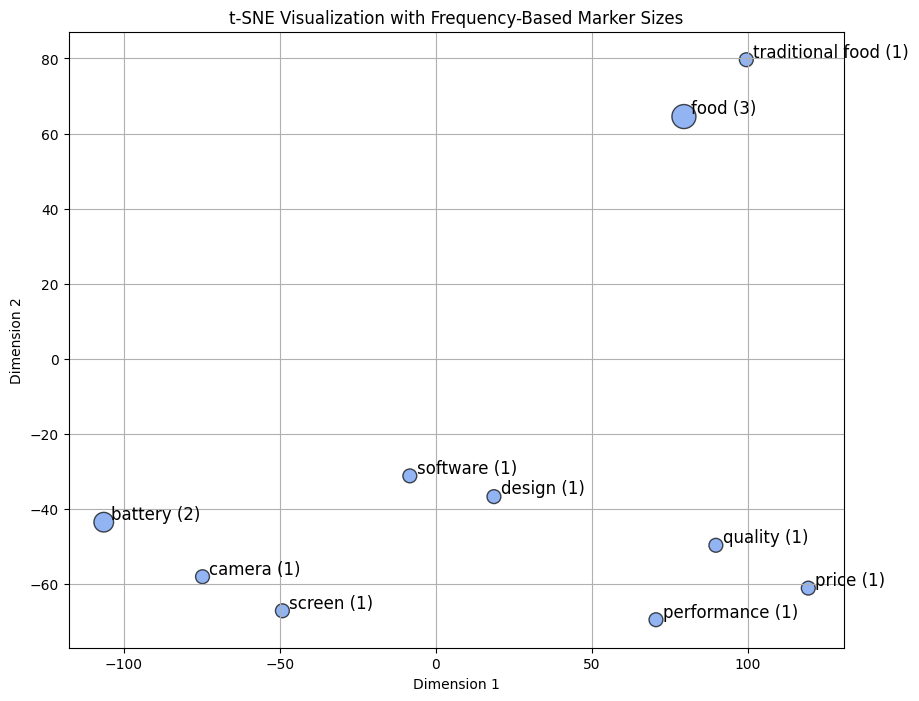

In [ ]:



# Example list with some words/phrases repeated
phrases = [
    "food", "traditional food", "battery", "performance",
    "design", "quality", "screen", "camera", "software", "price",
    "food", "food", "battery"  # 'food' appears three times, 'battery' twice.
]

# Count frequency for each unique phrase
phrase_counts = Counter(phrases)

# Determine the threshold for the top 10% counts
threshold = np.percentile(list(phrase_counts.values()), 90)

# Filter phrases to keep only those with counts above the threshold
top_phrases = [phrase for phrase, count in phrase_counts.items() if count >= threshold]
# Aggregate embeddings by averaging over multiple occurrences
unique_phrases = list(phrase_counts.keys())
unique_embeddings = []
for phrase in unique_phrases:
    # In a real scenario, if the context might differ for each occurrence,
    # you might want to compute embeddings for each occurrence and then average.
    # Here, we assume the same phrase leads to the same embedding.
    emb = get_embedding(phrase)
    unique_embeddings.append(emb)

unique_embeddings = np.array(unique_embeddings)

# ================================
# Dimensionality Reduction with t-SNE
# ================================
# Ensure perplexity is less than number of samples
tsne = TSNE(n_components=2, perplexity=3, random_state=42)
embeddings_2d = tsne.fit_transform(unique_embeddings)

# ================================
# Visualization with Marker Size Reflecting Frequency
# ================================
plt.figure(figsize=(10, 8))

# We use the frequency (count) to determine the size of each marker.
# Adjust the scaling factor as needed.
sizes = [phrase_counts[phrase] * 100 for phrase in unique_phrases]

scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      s=sizes, c='cornflowerblue', alpha=0.7, edgecolor='k')

# Annotate each point with its phrase and frequency
for i, phrase in enumerate(unique_phrases):
    plt.annotate(f"{phrase} ({phrase_counts[phrase]})",
                 (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                 fontsize=12, xytext=(5, 2), textcoords='offset points')

plt.title("t-SNE Visualization with Frequency-Based Marker Sizes")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()
